In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_score

import ML_V8_logistic_regression as lg

In [2]:
df=pd.read_csv("MaternalHealth.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


In [4]:
df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


In [5]:
categorical_col = df.select_dtypes("object").columns
categorical_col

Index(['Risk Level'], dtype='object')

In [6]:
df['Risk Level'].unique()

array(['High', 'Low', nan], dtype=object)

In [7]:
print(df.isnull().sum())

Age                        0
Systolic BP                5
Diastolic                  4
BS                         2
Body Temp                  0
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Gestational Diabetes       0
Mental Health              0
Heart Rate                 2
Risk Level                18
dtype: int64


In [8]:
# Popunjavanje medijanom za ključne zdravstvene parametre
cols_to_fix = ['Systolic BP', 'Diastolic', 'BS', 'BMI', 'Heart Rate']

for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

In [9]:
cols_categorical = ['Previous Complications', 'Preexisting Diabetes']

for col in cols_categorical:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# Brisanje redova gde je Risk Level nepoznat
df.dropna(subset=['Risk Level'], inplace=True)


In [11]:
print(df.isnull().sum())

Age                       0
Systolic BP               0
Diastolic                 0
BS                        0
Body Temp                 0
BMI                       0
Previous Complications    0
Preexisting Diabetes      0
Gestational Diabetes      0
Mental Health             0
Heart Rate                0
Risk Level                0
dtype: int64


In [12]:
df['Risk Level'].unique()

array(['High', 'Low'], dtype=object)

In [13]:
df['Risk Level']= df['Risk Level'].map({'Low':0, 'High':1})

In [14]:
df['Risk Level'].unique()

array([1, 0])

In [15]:
df.tail()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
1200,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,1
1201,25,110.0,90.0,6.0,98,19.0,0.0,0.0,1,1,92.0,1
1202,21,150.0,110.0,4.9,98,21.5,0.0,0.0,1,1,66.0,1
1203,23,130.0,100.0,5.1,98,27.0,0.0,0.0,1,1,60.0,1
1204,26,120.0,90.0,6.7,98,23.9,0.0,0.0,1,0,58.0,1


In [16]:
x = df.drop(columns='Risk Level')
y = df['Risk Level']

In [17]:
x.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0


In [18]:
y.info()

<class 'pandas.core.series.Series'>
Index: 1187 entries, 0 to 1204
Series name: Risk Level
Non-Null Count  Dtype
--------------  -----
1187 non-null   int64
dtypes: int64(1)
memory usage: 18.5 KB


In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [20]:
x_train.value_counts()

Age  Systolic BP  Diastolic  BS    Body Temp  BMI   Previous Complications  Preexisting Diabetes  Gestational Diabetes  Mental Health  Heart Rate
19   120.0        80.0       7.0   98         20.0  0.0                     0.0                   0                     0              70.0          4
                                              23.0  0.0                     0.0                   0                     0              70.0          3
31   120.0        60.0       6.1   98         23.0  0.0                     0.0                   0                     0              76.0          3
15   120.0        80.0       6.8   98         23.0  0.0                     0.0                   0                     0              70.0          2
17   90.0         63.0       6.9   98         23.0  0.0                     0.0                   0                     0              70.0          2
                                                                                                   

In [21]:
y_train.value_counts()

Risk Level
0    565
1    384
Name: count, dtype: int64

In [22]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [23]:
x_train

array([[ 0.25142458,  0.16776819, -0.14565755, ..., -0.36208903,
        -0.72676018, -0.82173267],
       [-0.70895884, -0.3604734 , -1.19976798, ..., -0.36208903,
        -0.72676018, -0.26925353],
       [ 0.14471531,  0.16776819,  0.20571259, ..., -0.36208903,
        -0.72676018,  0.00698604],
       ...,
       [ 0.78497093, -0.88871499, -0.49702769, ..., -0.36208903,
        -0.72676018, -1.3742118 ],
       [-0.28212177,  0.16776819,  1.61119316, ..., -0.36208903,
        -0.72676018, -1.3742118 ],
       [ 3.45270266,  0.16776819,  0.20571259, ..., -0.36208903,
        -0.72676018,  0.14510582]], shape=(949, 11))

## Modeling and Evaluation

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0])

[[145   3]
 [  4  86]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       148
           1       0.97      0.96      0.96        90

    accuracy                           0.97       238
   macro avg       0.97      0.97      0.97       238
weighted avg       0.97      0.97      0.97       238



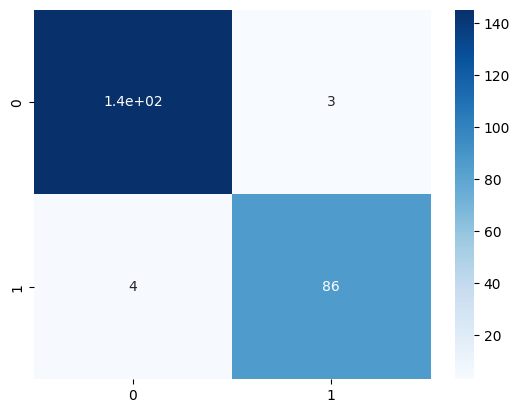

In [26]:
matrix1 = confusion_matrix(y_test, y_pred)
print(matrix1)
ax1 = sns.heatmap(matrix1, annot=True, cmap='Blues')
print(classification_report(y_test, y_pred)) 

In [27]:
weights = model.coef_[0]
bias = model.intercept_[0]

In [28]:
z = lg.logic_score(x_test[0], weights, bias)
print (z)

-6.811147277060751


In [29]:
bias

np.float64(-0.010854059681460242)

In [30]:
y_test.iloc[0]

np.int64(0)

#### Calculating z_scores for whole test_feature dataset

In [31]:
z_scores = []

for x in x_test:
    z_scores.append(lg.logic_score(x, weights, bias))
    

In [32]:
z_scores

[np.float64(-6.811147277060751),
 np.float64(-4.241867792577186),
 np.float64(10.57274371537483),
 np.float64(0.02582492032684914),
 np.float64(-5.448754174364856),
 np.float64(2.168841132317631),
 np.float64(12.768012730001876),
 np.float64(-4.636423052725263),
 np.float64(7.263578279609016),
 np.float64(9.020375224353042),
 np.float64(-3.2731436395982274),
 np.float64(-5.011704816983547),
 np.float64(9.329561055822344),
 np.float64(-7.493987291598296),
 np.float64(-6.096983814143238),
 np.float64(-6.38634521786645),
 np.float64(-4.32969867338035),
 np.float64(5.375689698536649),
 np.float64(-4.9760098834072615),
 np.float64(8.272959696031274),
 np.float64(7.062711571148076),
 np.float64(-5.733318579293453),
 np.float64(0.8987804717318549),
 np.float64(-3.7336961740783337),
 np.float64(8.302322759167206),
 np.float64(-3.07528198608261),
 np.float64(-5.465858449304019),
 np.float64(-5.767266102502269),
 np.float64(16.978280855699374),
 np.float64(-4.484128595703572),
 np.float64(-4.578

In [33]:
len(z_scores)

238

#### Conversion of z_scores into probabillities

In [34]:
probabilities = []

for z in z_scores:
    probabilities.append(lg.probbability(z))

In [35]:
probabilities

[0.0011002167210309392,
 0.014176833680693909,
 0.9999743961882098,
 0.5064558712863917,
 0.004283235448142197,
 0.8974163300187279,
 0.9999971494984038,
 0.009599265554136283,
 0.999299893877556,
 0.9998790938747418,
 0.03650410034752395,
 0.006615484241575915,
 0.9999112466880956,
 0.0005561104920341364,
 0.0022445933045003984,
 0.00168156864837912,
 0.013000282395265503,
 0.9953935912999992,
 0.006854240806591357,
 0.9997447366988308,
 0.9991442802730398,
 0.0032258794343268363,
 0.7106988247330418,
 0.02334624184345402,
 0.9997521212068794,
 0.04413844196844369,
 0.004210902672314044,
 0.0031185425496004626,
 0.9999999576916301,
 0.011160750284680684,
 0.010164884003808636,
 0.0038871688514141123,
 0.0789413288363603,
 0.0042451844294521136,
 0.002364290376303553,
 0.02946665556864642,
 0.0010203913850984488,
 0.05720798782049317,
 0.9222688282957008,
 0.9996936663399556,
 0.9995694202564533,
 0.883144247168462,
 0.006194035124186543,
 0.999338834444065,
 0.999854892307105,
 0.9999

#### Converting probabillities into prediction

In [36]:
predictions = lg.prediction(probabilities)

In [37]:
len(probabilities)

238

In [38]:
predictions

[0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0]

#### Checking if the prediciton is correct

In [39]:
index = 8
print(y_test.iloc[index])
print(predictions[index])

1
1


In [40]:
index = 114
print(y_test.iloc[index])
print(predictions[index])

1
1


[[145   3]
 [  4  86]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       148
           1       0.97      0.96      0.96        90

    accuracy                           0.97       238
   macro avg       0.97      0.97      0.97       238
weighted avg       0.97      0.97      0.97       238



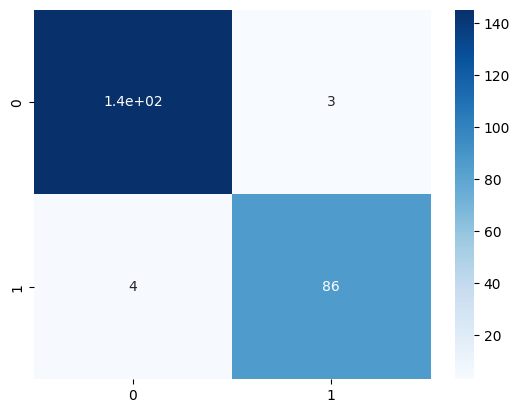

In [41]:
matrix2 = confusion_matrix(y_test, predictions)
print(matrix2)
ax1 = sns.heatmap(matrix2, annot=True, cmap='Blues')
print(classification_report(y_test, predictions)) 

## Zaključak 

##### Dobivena vrijednost z= -6.81 ukazuje na to kolika je „sigurnost“ modela. Negativan predznak u ovom slučaju rezultira vrlo niskom vjerovatnoćom (oko 0.11%) što model klasificira kao klasu 0 (Low Risk).



## K-Nearest Neighbour, Decission Tree algorithms

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

In [43]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)

y_pred_knn = model.predict(x_test)
y_pred_knn

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0])

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       148
           1       0.96      0.96      0.96        90

    accuracy                           0.97       238
   macro avg       0.96      0.96      0.96       238
weighted avg       0.97      0.97      0.97       238



Text(0.5, 1.0, 'KNN Confusion Matrix')

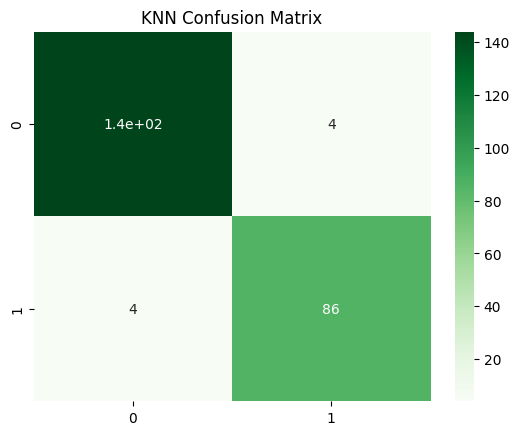

In [44]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, cmap="Greens")
print(classification_report(y_test,y_pred_knn))
plt.title("KNN Confusion Matrix")

In [46]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [48]:
y_pred_dt = dt_model.predict(x_test)

In [49]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

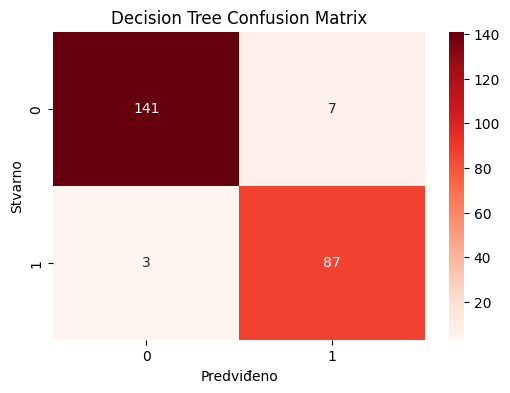

In [51]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Reds")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.show()

In [52]:
print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       148
           1       0.93      0.97      0.95        90

    accuracy                           0.96       238
   macro avg       0.95      0.96      0.96       238
weighted avg       0.96      0.96      0.96       238

